<a href="https://colab.research.google.com/github/akshat-mishra-ds/E-Commerce-Customer-Satisfaction-Score-Prediction/blob/main/DeepCSAT_E_Commerce_Customer_Satisfaction_Score_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - DeepCSAT: E-Commerce Customer Satisfaction Score Prediction



##### **Project Type**    - Deep Learning Classification Project
##### **Contribution**    - Individual
##### **Submitted by** - Akshat Mishra

# **Project Summary -**

This project focuses on predicting Customer Satisfaction (CSAT) Scores using Artificial Neural Networks (ANN). The dataset consists of customer support interactions collected from an e-commerce platform called Shopzilla over a one-month period. It contains information related to support channels, issue categories, product categories, customer feedback, order details, agent information, response times, and customer satisfaction ratings.

The primary objective of this project is to develop a deep learning model capable of accurately predicting customer satisfaction scores based on interaction-related features. Predicting CSAT scores in advance enables businesses to proactively identify dissatisfied customers, improve support quality, optimize agent performance, and enhance customer experience.

The project begins with comprehensive data exploration and cleaning. Missing values, duplicate records, and inconsistent data types are identified and handled appropriately. Several feature engineering techniques are applied to extract meaningful information from timestamps, including response time, order age, survey delay, and temporal patterns such as order month, day, and hour.

Categorical features are encoded using label encoding techniques, while numerical features are standardized to improve model performance. Customer remarks are transformed into machine-readable representations using TF-IDF vectorization to capture textual insights from customer feedback.

A Deep Learning Artificial Neural Network (ANN) is then designed and trained using TensorFlow and Keras. The architecture incorporates multiple dense layers, batch normalization, dropout regularization, and optimization techniques such as Early Stopping and Learning Rate Reduction to prevent overfitting and improve generalization.

Model performance is evaluated using multiple classification metrics including Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and Classification Reports. Business insights are extracted through exploratory data analysis and model interpretation techniques to understand factors influencing customer satisfaction.

Finally, the trained model is prepared for deployment using Streamlit, enabling real-time CSAT score predictions through an interactive web application.

This project demonstrates how deep learning can be leveraged to transform customer support data into actionable business intelligence, helping e-commerce organizations improve service quality and customer retention.

# **GitHub Link -**

https://github.com/akshat-mishra-ds/E-Commerce-Customer-Satisfaction-Score-Prediction

# **Problem Statement**


The objective of this project is to build a Deep Learning based Customer Satisfaction Prediction System that can accurately predict CSAT scores using customer support interaction data.

The model should learn patterns from customer support interactions, order information, agent performance metrics, response times, and customer remarks to estimate customer satisfaction levels.

Accurate prediction of customer satisfaction can help businesses:

1. Identify dissatisfied customers proactively.
2. Improve customer support processes.
3. Optimize agent performance.
4. Reduce customer churn.
5. Enhance customer experience.
6. Support data-driven decision making.

By leveraging Artificial Neural Networks (ANN), this project aims to capture complex nonlinear relationships within customer support data and generate reliable CSAT predictions.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [156]:
# ==========================
# Basic Libraries
# ==========================
import pandas as pd
import numpy as np

# ==========================
# Visualization Libraries
# ==========================
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# Ignore Warnings
# ==========================
import warnings
warnings.filterwarnings('ignore')

# ==========================
# Machine Learning Libraries
# ==========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import ( accuracy_score, classification_report, confusion_matrix )

# ==========================
# Deep Learning Libraries
# ==========================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ( Dense, Dropout, BatchNormalization )

from tensorflow.keras.callbacks import ( EarlyStopping, ReduceLROnPlateau )

print("Libraries Imported Successfully")

Libraries Imported Successfully


### Dataset Loading

In [157]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [158]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Specialization projects/DeepCSAT : Customer Satisfaction Score Prediction/eCommerce_Customer_support_data.csv')


### Dataset First View

In [159]:
# Display top 5 rows

df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [160]:
# Display bottom 5 rows

df.tail()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
85902,505ea5e7-c475-4fac-ac36-1d19a4cb610f,Inbound,Refund Related,Refund Enquiry,NaN,1b5a2b9c-a95f-405f-a42e-5b1b693f3dc9,NaN,30/08/2023 23:20,31/08/2023 07:22,31-Aug-23,NaN,NaN,NaN,NaN,Brandon Leon,Ethan Tan,William Kim,On Job Training,Morning,4
85903,44b38d3f-1523-4182-aba2-72917586647c,Inbound,Order Related,Seller Cancelled Order,Supported team customer executive good,d0e8a817-96d5-4ace-bb82-adec50398e22,NaN,31/08/2023 08:15,31/08/2023 08:17,31-Aug-23,NaN,NaN,NaN,NaN,Linda Foster,Noah Patel,Emily Chen,>90,Morning,5
85904,723bce2c-496c-4aa8-a64b-ca17004528f0,Inbound,Order Related,Order status enquiry,need to improve with proper details.,bdefe788-ccec-4eda-8ca4-51045e68db8a,NaN,31/08/2023 18:57,31/08/2023 19:02,31-Aug-23,NaN,NaN,NaN,NaN,Kimberly Martinez,Aiden Patel,Olivia Tan,On Job Training,Evening,5
85905,707528ee-6873-4192-bfa9-a491f1c08ab5,Inbound,Feedback,UnProfessional Behaviour,NaN,a031ec28-0c5e-450e-95b2-592342c40bc4,NaN,31/08/2023 19:59,31/08/2023 20:00,31-Aug-23,NaN,NaN,NaN,NaN,Daniel Martin,Olivia Suzuki,Olivia Tan,>90,Morning,4
85906,07c7a878-0d5a-42e0-97ef-de59abec0238,Inbound,Returns,Reverse Pickup Enquiry,NaN,3230db30-f8da-4c44-8636-ec76d1d3d4f3,NaN,31/08/2023 23:36,31/08/2023 23:37,31-Aug-23,NaN,NaN,NaN,NaN,Elizabeth Guerra,Nathan Patel,Jennifer Nguyen,On Job Training,Evening,5


### Dataset Rows & Columns count

In [161]:
# Dataset Rows & Columns count

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 85907
Columns : 20


### Dataset Information

In [162]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

In [163]:
# Statistical Summary

df.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


#### Missing Values/Null Values

In [164]:
# Missing Values/Null Values Count

missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

,0
connected_handling_time,85665
Customer_City,68828
Product_category,68711
Item_price,68701
order_date_time,68693
Customer Remarks,57165
Order_id,18232


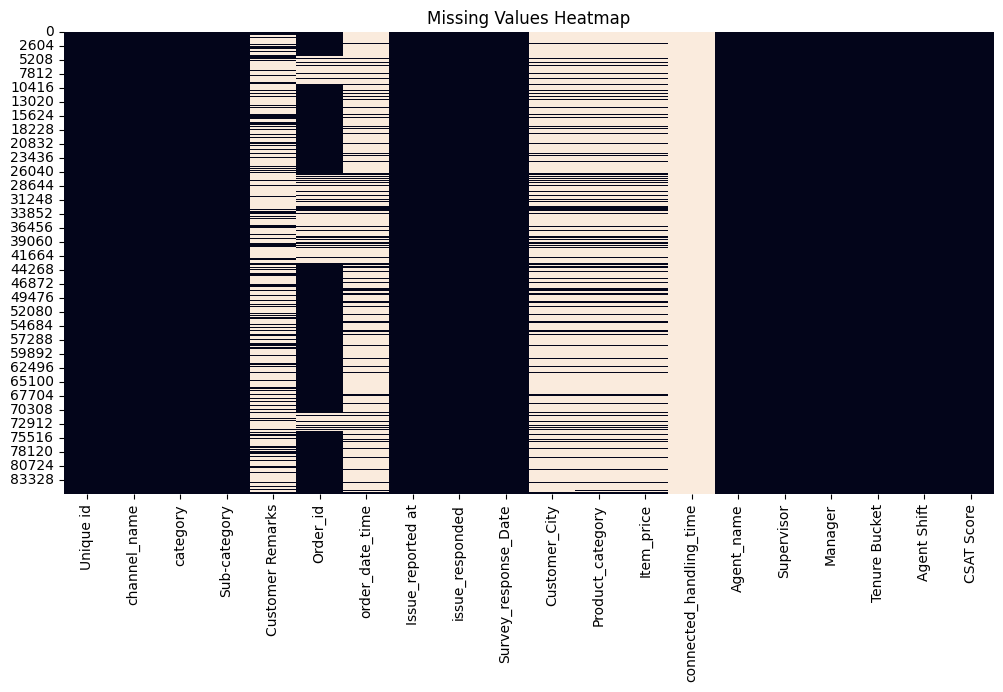

In [165]:
# Visualizing the missing values

plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

#### Duplicate Values

In [166]:
# Dataset Duplicate Value Count

duplicates = df.duplicated().sum()
print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


### What did you know about your dataset?

The dataset is large and rich in customer service information, but extensive missing values will require careful preprocessing and feature engineering before building a CSAT prediction model.

* The dataset contains **85,907 customer support interactions** with **20 features**, including customer details, order information, agent information, and the target variable (**CSAT Score**).
* The target variable **CSAT Score** ranges from **1 to 5**, with an average score of **4.24**, indicating generally positive customer satisfaction.
* The dataset has a **significant amount of missing data**, especially in:

  * **`connected_handling_time`** (99.7% missing)
  * **`Customer_City`, `Product_category`, `Item_price`**, and **`order_date_time`** (around 80% missing)
  * **`Customer Remarks`** (66.5% missing)
* Most columns are **categorical/text-based (17 out of 20)**, while only **2 columns are numerical features** and **1 is the target variable**.
* There are **no duplicate records**, indicating good data integrity.


## ***2. Understanding Your Variables***

In [167]:
# Dataset Columns
df.columns.tolist()

['Unique id',
 'channel_name',
 'category',
 'Sub-category',
 'Customer Remarks',
 'Order_id',
 'order_date_time',
 'Issue_reported at',
 'issue_responded',
 'Survey_response_Date',
 'Customer_City',
 'Product_category',
 'Item_price',
 'connected_handling_time',
 'Agent_name',
 'Supervisor',
 'Manager',
 'Tenure Bucket',
 'Agent Shift',
 'CSAT Score']

In [168]:
# Dataset Describe
df.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


In [169]:
# Separate numerical and categorical columns

categorical_features = df.select_dtypes(include=['object']).columns.tolist()
numerical_features = df.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\n")

print("Numerical Features:")
print(numerical_features)

Categorical Features:
['Unique id', 'channel_name', 'category', 'Sub-category', 'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at', 'issue_responded', 'Survey_response_Date', 'Customer_City', 'Product_category', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift']


Numerical Features:
['Item_price', 'connected_handling_time', 'CSAT Score']


In [170]:
# Number of categorical and numerical features

print("Total Features :", len(df.columns))
print("Categorical Features :", len(categorical_features))
print("Numerical Features :", len(numerical_features))

Total Features : 20
Categorical Features : 17
Numerical Features : 3


### Variables Description

The dataset contains customer support interactions from an e-commerce platform.

**Total Features:** 20

**Target Variable:** CSAT Score

The dataset includes structured, categorical, numerical, datetime, and textual features, making it suitable for deep learning classification modeling.

| Column Name | Description |
|------------|-------------|
| Unique id | Unique identifier for each customer interaction |
| channel_name | Customer service communication channel |
| category | Main category of customer issue |
| Sub-category | Detailed classification of customer issue |
| Customer Remarks | Feedback or comments provided by customer |
| Order_id | Unique order identifier |
| order_date_time | Date and time when order was placed |
| Issue_reported at | Date and time issue was reported |
| issue_responded | Date and time issue was responded to |
| Survey_response_Date | Date when customer submitted CSAT survey |
| Customer_City | Customer city |
| Product_category | Product category involved in issue |
| Item_price | Product price |
| connected_handling_time | Total handling time by support team |
| Agent_name | Support agent handling issue |
| Supervisor | Supervisor name |
| Manager | Manager name |
| Tenure Bucket | Experience bucket of agent |
| Agent Shift | Shift timing of support agent |
| CSAT Score | Customer Satisfaction Score (Target Variable) |

### Check Unique Values for each variable.

In [171]:
# Check Unique Values for each variable.

print("Unique values for each variable : ")

for column in df.columns:

    print("-"*45)
    print(column, " - ", df[column].nunique())

Unique values for each variable : 
---------------------------------------------
Unique id  -  85907
---------------------------------------------
channel_name  -  3
---------------------------------------------
category  -  12
---------------------------------------------
Sub-category  -  57
---------------------------------------------
Customer Remarks  -  18231
---------------------------------------------
Order_id  -  67675
---------------------------------------------
order_date_time  -  13766
---------------------------------------------
Issue_reported at  -  30923
---------------------------------------------
issue_responded  -  30262
---------------------------------------------
Survey_response_Date  -  31
---------------------------------------------
Customer_City  -  1782
---------------------------------------------
Product_category  -  9
---------------------------------------------
Item_price  -  2789
---------------------------------------------
connected_handling_time  -

## ***3. Data Wrangling***

The objective of this section is to:

1. Identify data quality issues.
2. Investigate missing values.
3. Analyze duplicate records.
4. Detect irrelevant features.
5. Prepare a clean dataset for further analysis.

At this stage, no feature engineering or preprocessing transformations will be performed.

### Data Wrangling Code

In [172]:
# Creating a copy of dataset

df_copy = df.copy()

print("Dataset copy created successfully.")

Dataset copy created successfully.


In [173]:
print("Rows :", df_copy.shape[0])
print("Columns :", df_copy.shape[1])

Rows : 85907
Columns : 20


In [174]:
# =============================================================
# Missing values count
# =============================================================

missing_values = df_copy.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)

,0
connected_handling_time,85665
Customer_City,68828
Product_category,68711
Item_price,68701
order_date_time,68693
Customer Remarks,57165
Order_id,18232


In [175]:
# =====================================================
# Missing Values Percentage
# =====================================================

missing_percentage = round(( df_copy.isnull().sum() / len(df_copy) ) * 100, 2)

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

missing_df[missing_df['Missing Count']>0].sort_values( by='Missing Percentage', ascending=False )

,Missing Count,Missing Percentage
connected_handling_time,85665,99.72
Customer_City,68828,80.12
Product_category,68711,79.98
Item_price,68701,79.97
order_date_time,68693,79.96
Customer Remarks,57165,66.54
Order_id,18232,21.22


In [176]:
# ==============================================
# Identifier column analysis
# ==============================================

identifier_columns = [
    'Unique id',
    'Order_id'
]

for col in identifier_columns:

    if col in df_copy.columns:

        print(col)

        print("Unique Values:",
              df_copy[col].nunique())

        print("Total Rows:",
              len(df_copy))

        print("-"*50)

Unique id
Unique Values: 85907
Total Rows: 85907
--------------------------------------------------
Order_id
Unique Values: 67675
Total Rows: 85907
--------------------------------------------------


In [177]:
# ========================================
# Data Type Analysis
# ========================================

df_copy.dtypes

,0
Unique id,object
channel_name,object
category,object
Sub-category,object
Customer Remarks,object
Order_id,object
order_date_time,object
Issue_reported at,object
issue_responded,object
Survey_response_Date,object


In [178]:
# =============================================
# Identify DateTime features
# =============================================

potential_datetime_columns = [

    'order_date_time',
    'Issue_reported at',
    'issue_responded',
    'Survey_response_Date'

]

potential_datetime_columns

['order_date_time',
 'Issue_reported at',
 'issue_responded',
 'Survey_response_Date']

In [179]:
# ================================================
# Target Variable Quality Check
# ================================================

df_copy['CSAT Score'].unique()

array([5, 4, 1, 3, 2])

In [180]:
df_copy['CSAT Score'].value_counts()

,count
CSAT Score,
5,59617
1,11230
4,11219
3,2558
2,1283


### What all manipulations have you done and insights you found?

**Data Wrangling Summary**

The following findings were observed:

1. Significant missing values exist in several important columns.
2. Duplicate records were investigated.
3. Unique id and Order_id behave as identifier variables.
4. Datetime columns were identified for future feature extraction.
7. Target variable quality was validated successfully.

The dataset is now ready for Exploratory Data Analysis and Data Visualization.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

The primary objectives of this section are:

1. Understand customer satisfaction patterns.
2. Analyze support channel performance.
3. Investigate product-related issues.
4. Examine agent-related performance.
5. Explore customer behavior.
6. Identify factors affecting CSAT scores.

The insights derived from this analysis can help improve customer support operations and enhance customer satisfaction.

#### Chart - 1 : Distribution of CSAT Scores

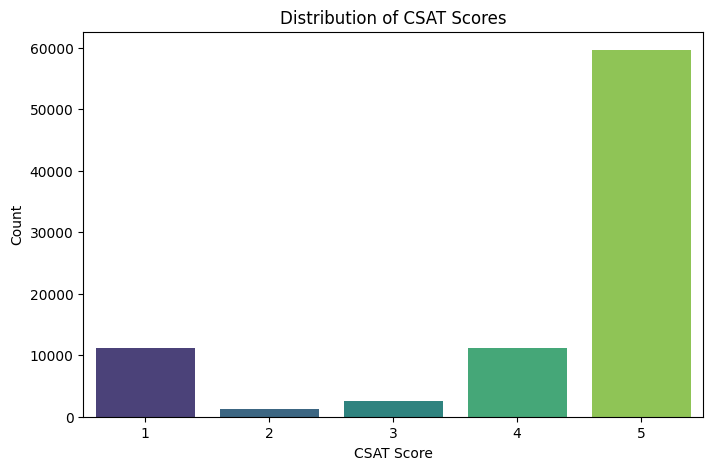

In [181]:
# Chart - 1 visualization code
plt.figure(figsize=(8,5))

sns.countplot( x='CSAT Score', data=df, palette='viridis' )

plt.title("Distribution of CSAT Scores")
plt.xlabel("CSAT Score")
plt.ylabel("Count")

plt.show()

##### 1. Why did you pick the specific chart?

Understanding the target variable distribution is essential before building a predictive model.

##### 2. What is/are the insight(s) found from the chart?

1. CSAT Score 5 dominates the dataset.
2. Ratings 2 and 3 occur less frequently.
3. Most customers appear satisfied with support interactions.
4. The dataset is imbalanced toward higher satisfaction scores.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The customer support team generally performs well, but special attention should be given to lower-rated interactions to identify recurring issues and reduce customer dissatisfaction.

#### Chart - 2 : Customer Support Channel Distribution

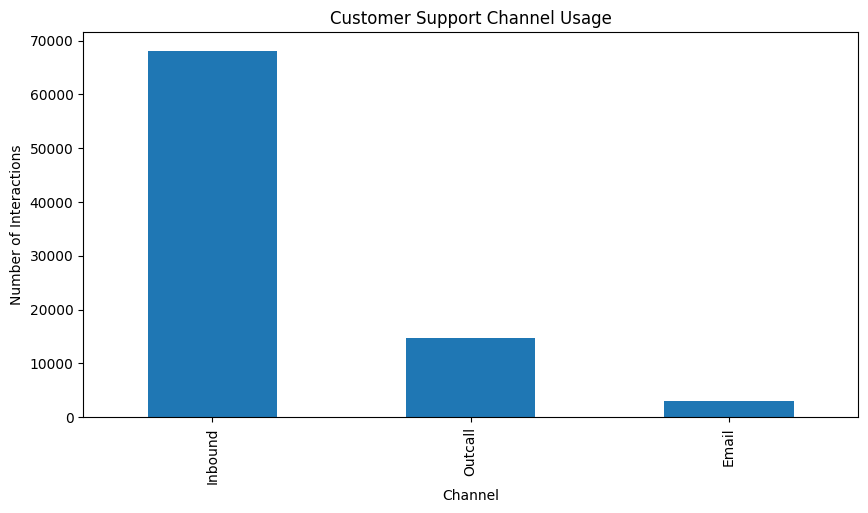

In [182]:
# Chart - 2 visualization code
plt.figure(figsize=(10,5))

df['channel_name'].value_counts().plot(kind='bar')

plt.title("Customer Support Channel Usage")
plt.xlabel("Channel")
plt.ylabel("Number of Interactions")
plt.show()

##### 1. Why did you pick the specific chart?

A **bar chart** is ideal for comparing the frequency of interactions across different customer support channels because it clearly shows differences in counts between categories.

##### 2. What is/are the insight(s) found from the chart?

* **Inbound** is the most used support channel with approximately **68,000 interactions**.
* **Outcall** has significantly fewer interactions (~15,000).
* **Email** is the least preferred channel with only around **3,000 interactions**.
* Customer support activity is heavily concentrated in the **Inbound** channel.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* The company should allocate more agents and resources to the **Inbound** channel since it handles the majority of customer interactions.
* The low usage of **Email** may indicate lower customer preference or awareness, requiring investigation.
* Understanding channel preferences can help optimize staffing, improve service quality, and reduce customer wait times.


#### Chart - 3 : Average CSAT Score by Channel

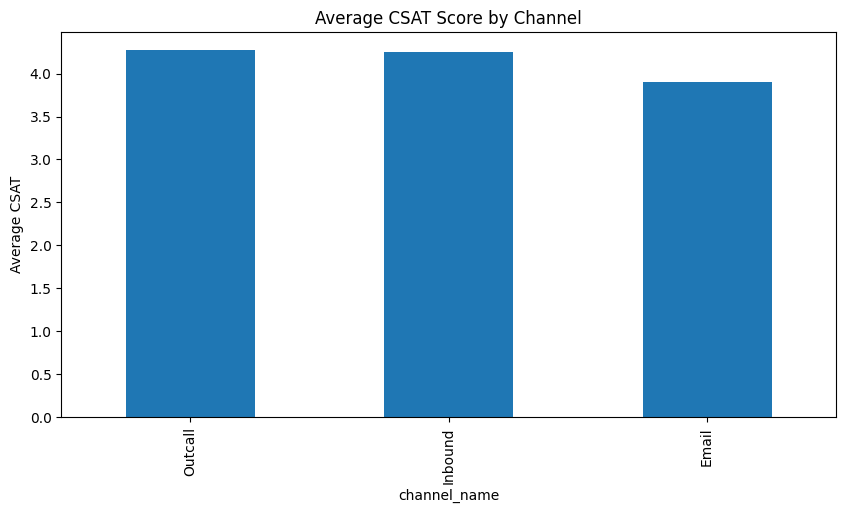

In [183]:
# Chart - 3 visualization code
channel_csat = df.groupby( 'channel_name' )['CSAT Score'].mean().sort_values( ascending=False )

plt.figure(figsize=(10,5))

channel_csat.plot( kind='bar')
plt.title("Average CSAT Score by Channel")
plt.ylabel("Average CSAT")
plt.show()

##### 1. Why did you pick the specific chart?

A **bar chart** is effective for comparing the **average CSAT score across different support channels**, making it easy to identify which channel delivers the highest customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

* **Outcall** has the highest average CSAT score (**~4.3**).
* **Inbound** performs similarly, with an average CSAT of around **4.2**.
* **Email** has the lowest average CSAT score (**~3.9**).
* Overall customer satisfaction is relatively high across all channels, but Email lags behind the others.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* The **Email** support channel may require process improvements, faster response times, or better issue resolution to improve customer satisfaction.
* Best practices from the **Outcall** channel can be analyzed and applied to other channels.
* Improving lower-performing channels can lead to higher overall customer satisfaction and customer retention.

#### Chart - 4 : Category-wise Interaction Volume

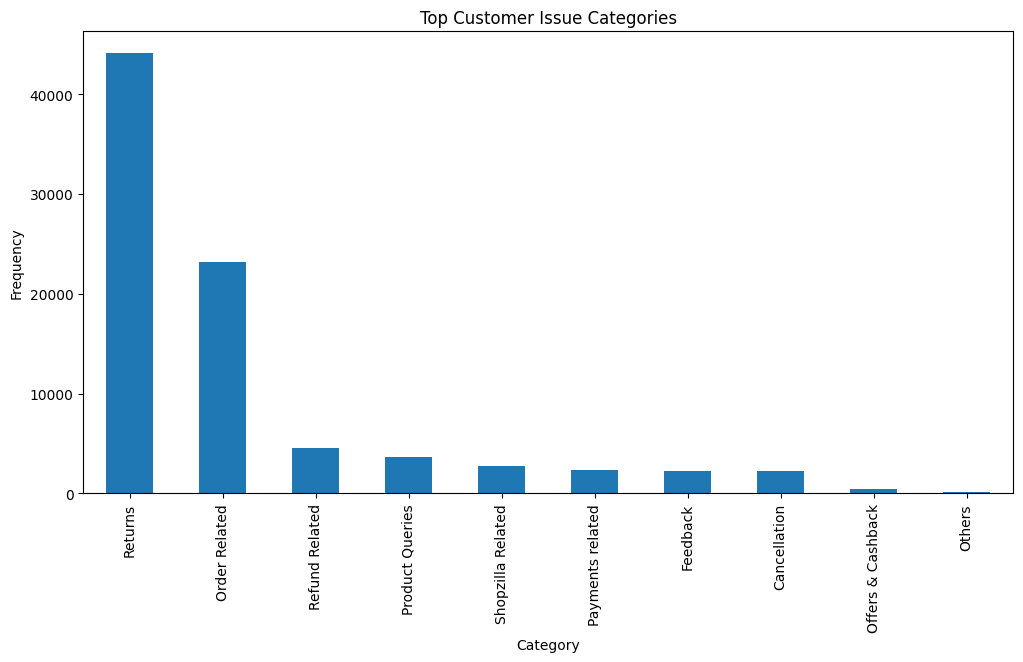

In [184]:
# Chart - 4 visualization code
plt.figure(figsize=(12,6))

df['category'].value_counts().head(10).plot(kind='bar')

plt.title("Top Customer Issue Categories")
plt.xlabel("Category")
plt.ylabel("Frequency")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is suitable for comparing the frequency of customer issues across different categories and quickly identifying the most common problem areas.

##### 2. What is/are the insight(s) found from the chart?

* **Returns** is the most reported issue category with over **44,000 cases**, accounting for more than half of all complaints.
* **Order Related** issues are the second most common, with around **23,000 cases**.
* **Refund Related** and **Product Queries** follow but at significantly lower frequencies.
* Categories such as **Offers & Cashback** and **Others** contribute very few complaints.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Reducing issues related to **Returns** and **Order Management** can significantly lower customer support workload.
* Improving product quality, order accuracy, and return processes could greatly enhance customer satisfaction.
* Focusing resources on the top complaint categories will provide the highest impact on customer experience and operational efficiency.

#### Chart - 5 : Product Category vs Average CSAT

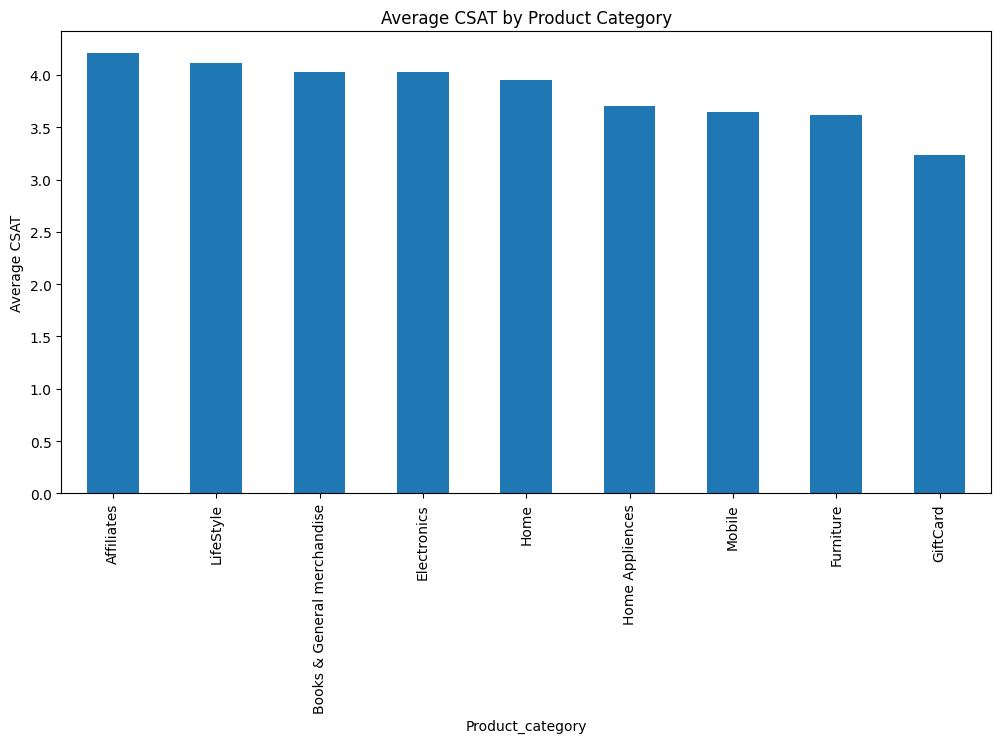

In [185]:
# Chart - 5 visualization code
product_csat = df.groupby( 'Product_category' )['CSAT Score'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12,6))

product_csat.plot(kind='bar')
plt.title("Average CSAT by Product Category")
plt.ylabel("Average CSAT")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is effective for comparing the average CSAT scores across different product categories, helping identify which product categories deliver better or worse customer experiences.

##### 2. What is/are the insight(s) found from the chart?

* **Affiliates** has the highest average CSAT score (**~4.2**), indicating the highest customer satisfaction.
* **Lifestyle**, **Electronics**, and **Books & General Merchandise** also maintain strong satisfaction scores above **4.0**.
* **GiftCard** has the lowest average CSAT score (**~3.2**), significantly below other categories.
* **Mobile**, **Furniture**, and **Home Appliances** show comparatively lower satisfaction levels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* The **GiftCard** category requires immediate attention to identify and resolve customer pain points.
* High-performing categories such as **Affiliates** and **Lifestyle** can be studied to replicate successful practices across other product categories.
* Improving customer experience in low-CSAT categories can increase customer retention, reduce complaints, and enhance overall brand perception.

#### Chart - 6 : Agent Shift vs CSAT Score

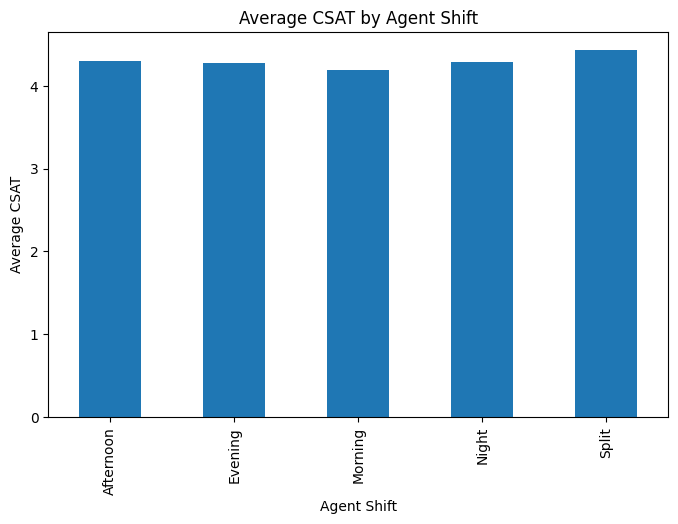

In [186]:
# Chart - 6 visualization code
shift_csat = df.groupby( 'Agent Shift' )['CSAT Score'].mean()

plt.figure(figsize=(8,5))

shift_csat.plot(kind='bar')

plt.title("Average CSAT by Agent Shift")
plt.ylabel("Average CSAT")
plt.show()

##### 1. Why did you pick the specific chart?

A **bar chart** is ideal for comparing the **average CSAT scores across different agent shifts**, making it easy to identify whether customer satisfaction varies by shift timing.

##### 2. What is/are the insight(s) found from the chart?

* **Split Shift** has the highest average CSAT score (**~4.4**).
* **Morning Shift** has the lowest average CSAT score (**~4.2**).
* The difference in CSAT across shifts is relatively small, indicating consistent service quality.
* Overall customer satisfaction remains high across all shifts.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* The performance of the **Split Shift** team can be analyzed to identify best practices and improve other shifts.
* Since satisfaction levels are fairly consistent, current staffing and support processes appear effective.
* Additional training or workload analysis for the **Morning Shift** may help further improve customer satisfaction.

#### Chart - 7 : Tenure Bucket vs CSAT Score

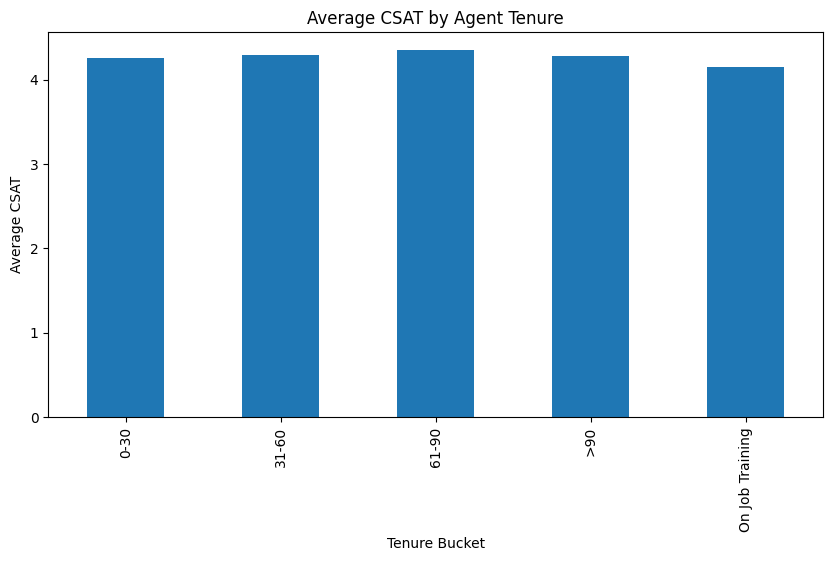

In [187]:
# Chart - 7 visualization code
tenure_csat = df.groupby( 'Tenure Bucket' )['CSAT Score'].mean()

plt.figure(figsize=(10,5))

tenure_csat.plot( kind='bar' )

plt.title("Average CSAT by Agent Tenure")
plt.ylabel("Average CSAT")
plt.show()

##### 1. Why did you pick the specific chart?

A **bar chart** is useful for comparing the **average CSAT scores across different agent tenure groups**, helping determine whether agent experience impacts customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

* Agents with **61–90 days tenure** have the highest average CSAT score (**~4.35**).
* **On Job Training (OJT)** agents have the lowest average CSAT score (**~4.15**).
* CSAT scores remain consistently high across all tenure groups, with only minor variations.
* Customer satisfaction appears to improve as agents gain experience, peaking around the **61–90 day** tenure range.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* The lower CSAT score for **OJT agents** highlights the need for enhanced training and mentoring programs.
* The strong performance of agents in the **61–90 day** tenure bucket suggests that experience positively influences service quality.
* Sharing best practices from high-performing experienced agents can help accelerate the development of newer agents and improve overall customer satisfaction.

#### Chart - 8 : Item Price Distribution

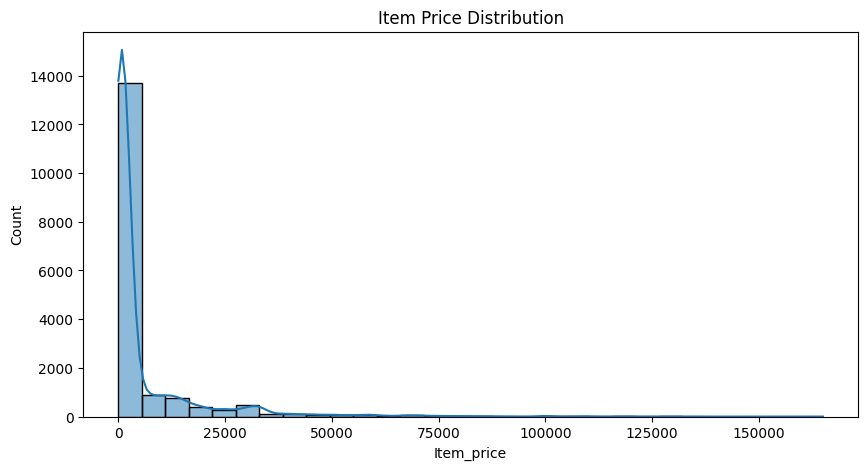

In [188]:
# Chart - 8 visualization code
plt.figure(figsize=(10,5))

sns.histplot( df['Item_price'], bins=30, kde=True, palette='viridis' )

plt.title("Item Price Distribution")

plt.show()

##### 1. Why did you pick the specific chart?

A **histogram with KDE curve** is appropriate for visualizing the distribution of a numerical variable like **Item Price**, helping identify skewness, concentration, and outliers.

##### 2. What is/are the insight(s) found from the chart?

* The distribution is **highly right-skewed**, with most items concentrated in the lower price range.
* A large majority of products are priced below **₹10,000**.
* There are a few extremely expensive items reaching up to **₹165,000**, indicating the presence of outliers.
* The mean item price (**₹5,661**) is much higher than the median (**₹979**), further confirming the skewed distribution.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Customer interactions are primarily related to **low- and mid-priced products**, suggesting these categories drive most sales volume.
* High-priced items, although fewer in number, may require specialized customer support due to their higher value.
* The presence of extreme outliers should be considered during modeling, as they may affect predictive performance and statistical analysis.


#### Chart - 9 : Connected Handling Time Distribution

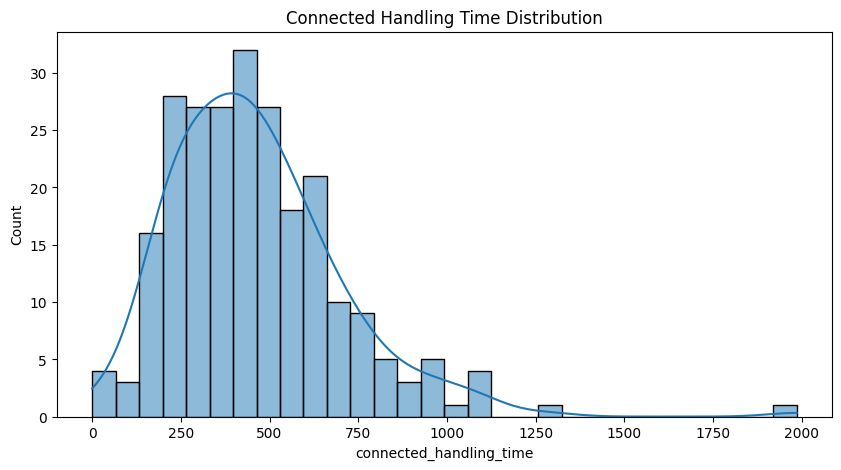

In [189]:
# Chart - 9 visualization code
plt.figure(figsize=(10,5))

sns.histplot(
    df['connected_handling_time'],
    bins=30,
    kde=True
)

plt.title("Connected Handling Time Distribution")

plt.show()

##### 1. Why did you pick the specific chart?

A **histogram with a KDE curve** is suitable for analyzing the distribution of **Connected Handling Time**, helping identify the typical handling duration, spread, and potential outliers.

##### 2. What is/are the insight(s) found from the chart?

* Most customer interactions have a handling time between **200 and 700 seconds**.
* The distribution is **positively skewed**, with a long tail extending toward higher handling times.
* The average handling time is approximately **462 seconds (7.7 minutes)**.
* A few cases have exceptionally high handling times (up to **1,986 seconds**), indicating potential outliers or complex customer issues.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Most customer issues are resolved within a reasonable time frame, suggesting efficient support operations.
* Cases with very high handling times should be investigated to identify process bottlenecks or recurring complex issues.
* Reducing long-duration interactions can improve agent productivity, reduce customer wait times, and enhance overall customer satisfaction.

#### Chart - 10 : Correlation Heatmap

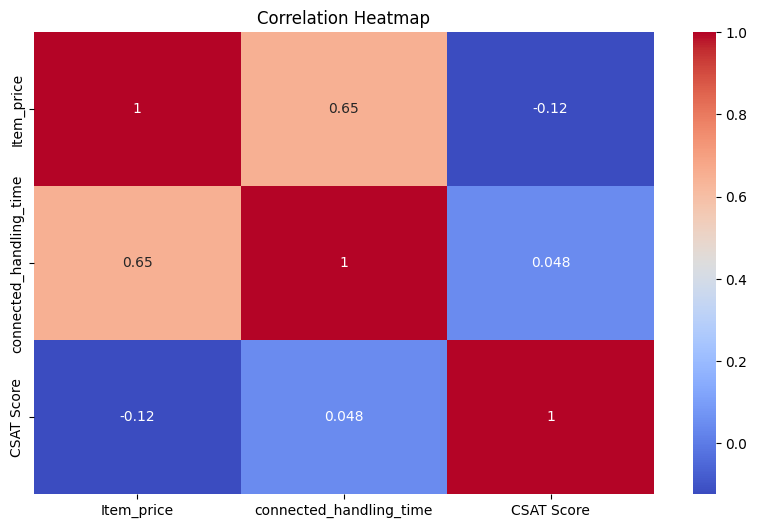

In [190]:
# Correlation Heatmap visualization code
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(
        include=np.number
    ).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

##### 1. Why did you pick the specific chart?

A **correlation heatmap** is useful for understanding the strength and direction of relationships between numerical variables. It helps identify which features may influence the target variable (**CSAT Score**).

##### 2. What is/are the insight(s) found from the chart?

* **Item Price** and **Connected Handling Time** show a **moderate positive correlation (0.65)**, indicating that higher-priced products tend to require longer handling times.
* **Connected Handling Time** has **almost no correlation (0.048)** with **CSAT Score**, suggesting that longer or shorter handling times do not significantly impact customer satisfaction.
* **Item Price** has a **very weak negative correlation (-0.12)** with **CSAT Score**, indicating that product price has little influence on customer satisfaction.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Hypothesis testing is used to determine whether relationships observed in the data are statistically significant or occurred by chance.

We will test a few business-related hypotheses to understand factors influencing customer satisfaction, which are written below :

- Does customer support channel affect CSAT Score?
- Does agent experience (Tenure Bucket) affect customer satisfaction?
- Does product category influence customer satisfaction?

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀)** : There is no relationship between support channel and CSAT Score.

**Alternative Hypothesis (H₁)** : There is a significant relationship between support channel and CSAT Score.

#### 2. Perform an appropriate statistical test.

In [191]:
from scipy.stats import chi2_contingency

# Perform Statistical Test to obtain P-Value
channel_csat = pd.crosstab(
    df['channel_name'],
    df['CSAT Score']
)

chi2, p_value, dof, expected = chi2_contingency(channel_csat)

if p_value < 0.05:
  print("We successfully rejected the null hypothesis. \nThere is a statistically significant relationship between support channel and customer satisfaction.")
else:
  print("Failed to reject the null hypothesis.")


We successfully rejected the null hypothesis. 
There is a statistically significant relationship between support channel and customer satisfaction.


##### Which statistical test have you done to obtain P-Value?

I used the Chi-Square Test of Independence because both variables, Support Channel and CSAT Score, are categorical in nature.

##### Why did you choose the specific statistical test?

The test is appropriate when:
- Both variables are categorical
- Data is represented in a contingency table (cross-tabulation)
- We want to determine whether the variables are independent or associated

Since the objective was to check whether support channel affects CSAT Score, the Chi-Square Test is the correct statistical test.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀) :** Agent tenure and CSAT Score are independent.

**Alternative Hypothesis (H₁) :** Agent tenure influences CSAT Score.

#### 2. Perform an appropriate statistical test.

In [192]:
# Perform Statistical Test to obtain P-Value
tenure_csat = pd.crosstab(
    df['Tenure Bucket'],
    df['CSAT Score']
)

chi2, p_value, dof, expected = chi2_contingency(tenure_csat)

if p_value < 0.05:
  print("We have successfully reject the null hypothesis. \nmeans There is a statistically significant association between an agent's tenure and customer satisfaction (CSAT) score.")
else:
  print("Failed to reject the null hypothesis.")


We have successfully reject the null hypothesis. 
means There is a statistically significant association between an agent's tenure and customer satisfaction (CSAT) score.


##### Which statistical test have you done to obtain P-Value?

Chi-Square Test of Independence

##### Why did you choose the specific statistical test?

 I choose the this test because:

- Tenure Bucket is a categorical variable.
- CSAT Score is a categorical/ordinal variable.

We want to determine whether there is an association between two categorical variables.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀) :** Product category and CSAT Score are independent.

**Alternative Hypothesis (H₁) :** Product category significantly affects CSAT Score.

#### 2. Perform an appropriate statistical test.

In [193]:
# Perform Statistical Test to obtain P-Value
product_csat = pd.crosstab(
    df['Product_category'],
    df['CSAT Score']
)

chi2, p_value, dof, expected = chi2_contingency(product_csat)

if p_value < 0.05:
  print("We have successfully reject the null hypothesis. \nThere is a statistically significant association between Product Category and CSAT Score.")
else:
  print("Failed to reject the null hypothesis.")

We have successfully reject the null hypothesis. 
There is a statistically significant association between Product Category and CSAT Score.


##### Which statistical test have you done to obtain P-Value?

Chi-Square Test of Independence

##### Why did you choose the specific statistical test?

The Chi-Square Test of Independence was selected because:

Product Category is a categorical variable.
CSAT Score is a categorical/ordinal variable.
The objective is to determine whether there is an association between these two categorical variables.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [194]:
# Create a copy of the dataset

df_final = df.copy()

print("Working dataset created successfully.")

Working dataset created successfully.


In [195]:
# Remove unique id and order_id
columns_to_drop = [ 'Unique id', 'Order_id', 'Agent_name', 'Customer_City' ]

for col in columns_to_drop:

    if col in df_final.columns:

        df_final.drop(col, axis=1, inplace=True)

print("Identifier columns removed successfully.")

Identifier columns removed successfully.


In [196]:
# Missing customer remarks filled with 'No remark'
df_final['Customer Remarks'] = df_final['Customer Remarks'].fillna('No Remark')

In [197]:
# Missing Product category filled with 'Unknown'
df_final['Product_category'] = df_final['Product_category'].fillna('Unknown')

In [198]:
# Missing 'Item_price' filled with median
df_final['Item_price'] = df_final['Item_price'].fillna(df_final['Item_price'].median())

In [199]:
# Missing 'connected_handling_time' filled with median
df_final['connected_handling_time'] = df_final['connected_handling_time'].fillna(df_final['connected_handling_time'].median())

In [200]:
numeric_columns = df_final.select_dtypes(
    include=np.number
).columns

for col in numeric_columns:

    df_final[col].fillna(
        df_final[col].median(),
        inplace=True
    )

#### What all missing value imputation techniques have you used and why did you use those techniques?


Missing values must be handled before training the neural network.

Different strategies are used depending on the feature type:

**Text Features**
- Replace with "No Remark"

**Categorical Features**
- Replace with "Unknown"

**Numerical Features**
- Replace with Median

Median is preferred because it is robust against outliers.

---

**Unique id & Order_id** columns do not provide meaningful information for predicting customer satisfaction and may introduce noise into the model, thats why i removed these columns.

Removed **Agent_Name & Customer_City** because Label encoding these destroys ANN performance.

### 2. Categorical Encoding

In [201]:
# ==================================================
# One-Hot Encoding for Categorical Variables
# ==================================================

df_final = pd.get_dummies(
    df_final,
    columns=[
        'channel_name',
        'category',
        'Sub-category',
        'Product_category',
        'Supervisor',
        'Manager',
        'Tenure Bucket',
        'Agent Shift'
    ],
    drop_first=True
)

In [202]:
# ==================================================
# Customer Remark Length
# ==================================================

df_final['Remark_Length'] = ( df['Customer Remarks'].fillna('').str.len() )


In [203]:
# Remove the original text column after extracting useful information from it
# This converts unstructured text into a numerical feature

df_final.drop( 'Customer Remarks', axis=1, inplace = True )

#### What all categorical encoding techniques have you used & why did you use those techniques?

For neural-network-based modeling, One-Hot Encoding is generally preferred for nominal categorical variables because it avoids introducing artificial ordering. Therefore, the final model was trained using the One-Hot Encoded features.

### 3. Date Time Feature Engineering

The dataset contains several timestamp columns.

However, **a large proportion of records have missing datetime values, particularly in the order_date_time feature.**

Instead of dropping these records,
- we create missing-value indicators and derive meaningful time-based features wherever information is available.

This approach helps preserve valuable information while minimizing data loss.

In [204]:
# =======================================================
# Convert datetime columns
# =======================================================

datetime_columns = [
    'order_date_time', 'Issue_reported at',
    'issue_responded', 'Survey_response_Date'
]

for col in datetime_columns:

    df_final[col] = pd.to_datetime(df_final[col], errors='coerce')

print("Datetime conversion completed.")

Datetime conversion completed.


In [205]:
# =======================================================
# Missing indicator (Preserve Missingness Information)
# =======================================================

df_final['Order_Date_Missing'] = (
    df_final['order_date_time'].isnull().astype(int)
)

df_final['Issue_Reported_Missing'] = (
    df_final['Issue_reported at'].isnull().astype(int)
)

df_final['Issue_Responded_Missing'] = (
    df_final['issue_responded'].isnull().astype(int)
)

df_final['Survey_Date_Missing'] = (
    df_final['Survey_response_Date'].isnull().astype(int)
)

In [206]:
# ===================================================
# Response Time
# ===================================================

# Time taken to respond to issue

df_final['Response_Time_Hours'] = ( df_final['issue_responded'] - df_final['Issue_reported at'] ).dt.total_seconds() / 3600

In [207]:
# ===================================================
# Response Time
# ===================================================

# Time between response and survey submission

df_final['Survey_Delay_Hours'] = ( df_final['Survey_response_Date'] - df_final['issue_responded'] ).dt.total_seconds() / 3600

In [208]:
# ===================================================
# Order Age
# ===================================================

# Time between order placement and issue reporting

df_final['Order_Age_Hours'] = ( df_final['Issue_reported at'] - df_final['order_date_time'] ).dt.total_seconds() / 3600

In [209]:
# ===================================================
# Extract Time Components
# ===================================================

# Extract components only when date exists

df_final['Order_Hour'] = ( df_final['order_date_time'].dt.hour )

df_final['Order_Day'] = ( df_final['order_date_time'].dt.dayofweek )

df_final['Order_Month'] = ( df_final['order_date_time'].dt.month )

In [210]:
# ===================================================
# Impute Engineered Numerical Features
# ===================================================

engineered_features = [
    'Response_Time_Hours',
    'Survey_Delay_Hours',
    'Order_Age_Hours',
    'Order_Hour',
    'Order_Day',
    'Order_Month'
]

for col in engineered_features:

    df_final[col].fillna( df_final[col].median() , inplace=True )

In [211]:
# ==============================================
# Drop original DateTime columns
# ==============================================

df_final.drop( columns = datetime_columns, inplace=True )

In [212]:
df_final[[

    'Order_Date_Missing',
    'Issue_Reported_Missing',
    'Issue_Responded_Missing',
    'Survey_Date_Missing',
    'Response_Time_Hours',
    'Survey_Delay_Hours',
    'Order_Age_Hours'

]].head()

,Order_Date_Missing,Issue_Reported_Missing,Issue_Responded_Missing,Survey_Date_Missing,Response_Time_Hours,Survey_Delay_Hours,Order_Age_Hours
0,1,0,0,0,0.566667,4908.216667,1511.9
1,1,0,0,0,0.033333,4907.100000,1511.9
2,1,0,0,0,0.366667,4899.366667,1511.9
3,1,0,0,0,0.333333,4898.733333,1511.9
4,1,0,0,0,0.033333,4909.466667,1511.9


In [213]:
# Response speed category

df_final['Fast_Response'] = ( df_final['Response_Time_Hours'] < 1 ).astype(int)

# Long order age

df_final['Old_Order'] = ( df_final['Order_Age_Hours'] > 1000 ).astype(int)

# Long survey delay

df_final['Delayed_Survey'] = ( df_final['Survey_Delay_Hours'] > 1000 ).astype(int)

#### Summary of Datetime Feature Engineering

To address the challenge of very high percentage of missing values in date time columns, specially **`order_date_time`**, a missing value indicator approach was used.
New binary features such as
- `Order_Date_Missing`,
- `Issue_Reported_Missing`,
- `Issue_Responded_Missing`, and
- `Survey_Date_Missing`

were created to explicitly capture whether the original datetime information was missing. This allows the model to learn patterns associated with missing timestamps, which may itself be an important signal.

Several business-relevant features were then engineered from the available datetime information:

- **Response_Time_Hours:** Measures the time taken by the support team to respond to a reported issue.
- **Survey_Delay_Hours:** Measures the delay between issue resolution and customer survey submission.
- **Order_Age_Hours:** Captures the duration between order placement and issue reporting.
- **Order_Hour, Order_Day, and Order_Month:** Extract temporal patterns that may influence customer satisfaction.

After feature extraction, missing values in the newly created numerical features were imputed using the median to maintain dataset completeness while minimizing the impact of outliers. Finally, the original datetime columns were removed because their information had already been transformed into more meaningful and model-friendly features.

**This approach preserves all available records, captures valuable temporal behavior, and provides the neural network with richer information for predicting customer satisfaction scores.**

### 4. Feature Manipulation & Selection

In [214]:
# =====================================================
# Defining Features and Target Variable
# =====================================================

X = df_final.drop('CSAT Score', axis=1)

# Convert classes from:
# 1,2,3,4,5
# to
# 0,1,2,3,4

y = df_final['CSAT Score'] - 1

print("Target Classes:")
print(sorted(y.unique()))

Target Classes:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


##### What all feature selection methods have you used  and why?

In this project, I did not apply a separate feature selection algorithm.

I initially retained all engineered features except the target variable (CSAT Score) and allowed the machine learning model to learn the importance of each feature.

Before modeling, I performed EDA, correlation analysis, and hypothesis testing to understand feature relevance and relationships with the target.

##### Which all features you found important and why?

- The most influential features were `Product Category`, `Channel Name`, `Tenure Bucket`, `Category`, and `Sub-category` because they showed significant associations with CSAT Score.
- Numerical features such as `Item Price` and `Connected Handling Time` appeared less influential due to their weak correlation with the target variable.

### 5. Data Scaling

In [215]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##### Which method have you used to scale you data and why?

Artificial Neural Networks perform better when features are standardized.

StandardScaler transforms features to have:
- Mean = 0
- Standard Deviation = 1

### 6. Data Splitting

In [216]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y

)

##### What data splitting ratio have you used and why?

The dataset is divided into:

- 80% Training Data
- 20% Testing Data

Stratified sampling is used to preserve class distribution.

In [217]:
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features : (68725, 146)
Testing Features : (17182, 146)
Training Target : (68725,)
Testing Target : (17182,)


The following preprocessing steps were completed:

1. Removed identifier columns.
2. Handled missing values.
3. Engineered time-based features.
4. Created customer remark indicator.
5. Encoded categorical features.
6. Standardized numerical variables.
7. Split the dataset into training and testing sets.

The dataset is now ready for ANN model development.

In [218]:
from sklearn.dummy import DummyClassifier

# ==================================================
# Baseline Model using Dummy Classifier
# ==================================================

# Create a baseline classifier that always predicts
# the most frequent class in the training dataset
dummy = DummyClassifier(
    strategy='most_frequent'
)

# Train the baseline model
dummy.fit(X_train, y_train)

# Evaluate baseline performance on test data
# Accuracy represents the minimum benchmark that
# any machine learning model should outperform
print(
    "Baseline Accuracy:",
    dummy.score(X_test, y_test)
)

Baseline Accuracy: 0.6939820742637645


### 7. Handling Class Imbalance

In [219]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(
    zip(classes, class_weights)
)

class_weight_dict


{np.int64(0): np.float64(1.5299421193232414),
 np.int64(1): np.float64(13.383641674780915),
 np.int64(2): np.float64(6.717986314760508),
 np.int64(3): np.float64(1.5314763231197772),
 np.int64(4): np.float64(0.288197429392154)}

To address class imbalance, I used the Class Weighting technique. I calculated balanced class weights using Scikit-learn's `compute_class_weight()` function and passed these weights to the model during training.

I chose this approach because :
- It preserves the original dataset,
- Avoids generating synthetic samples, and
- Helps the model pay more attention to underrepresented CSAT classes.

This reduces bias toward majority classes and improves learning across all rating categories.

## ***7. ML Model Implementation***

### Build ANN Architecture

In [220]:
# ==================================================
# Artificial Neural Network (ANN) Model Architecture
# ==================================================

# Create a Sequential Neural Network
model = Sequential([

    # ==================================================
    # Input Layer + Hidden Layer 1
    # ==================================================
    # 128 neurons with ReLU activation
    # Input shape equals the number of features
    Dense( 128, activation='relu', input_shape=(X_train.shape[1],) ),
    BatchNormalization(),
    Dropout(0.20),


    # ==================================================
    # Hidden Layer 2
    # ==================================================
    # 64 neurons with ReLU activation
    # Learns higher-level feature representations
    Dense( 64, activation='relu' ),
    BatchNormalization(),
    Dropout(0.20),


    # ==================================================
    # Hidden Layer 3
    # ==================================================
    # 32 neurons with ReLU activation
    # Captures deeper non-linear relationships
    Dense( 32, activation='relu' ),


    # ==================================================
    # Output Layer
    # ==================================================
    # 5 neurons because CSAT Score has 5 classes
    # Softmax converts outputs into class probabilities
    Dense( 5, activation='softmax' )

])

### Model Summary

In [221]:
# ==================================================
# Model Summary
# ==================================================

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,085 (117.52 KB)

 Trainable params: 29,701 (116.02 KB)

 Non-trainable params: 384 (1.50 KB)

### Model Compilation

In [222]:
# ==================================================
# Model Compilation
# ==================================================

model.compile(

    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']

)

### Define Callbacks

In [223]:
# ==================================================
# Callback 1: Early Stopping
# ==================================================
# Stops training when validation loss stops improving.
# Helps prevent overfitting and saves training time.
#
# monitor='val_loss'
#   -> Tracks validation loss during training
#
# patience=5
#   -> Waits for 5 consecutive epochs without improvement
#      before stopping training
#
# restore_best_weights=True
#   -> Restores the model weights from the epoch with
#      the lowest validation loss

early_stopping = EarlyStopping(

    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True

)


# ==================================================
# Callback 2: Reduce Learning Rate on Plateau
# ==================================================
# Reduces the learning rate when validation loss
# stops improving.
#
# monitor='val_loss'
#   -> Tracks validation loss
#
# factor=0.5
#   -> Reduces learning rate by 50%
#
# patience=3
#   -> Waits for 3 epochs without improvement before
#      reducing the learning rate
#
# verbose=1
#   -> Displays messages whenever learning rate changes

reduce_lr = ReduceLROnPlateau(

    monitor = 'val_loss',
    factor = 0.5,
    patience = 3,
    verbose = 1

)

### Train Model

In [224]:
# ==================================================
# Train the Artificial Neural Network (ANN)
# ==================================================

history = model.fit(

    # Training feature set
    X_train,

    # Training target labels
    y_train,

    # Reserve 20% of training data for validation
    # Used to monitor model performance on unseen data
    validation_split = 0.20,

    # Number of complete passes through the training dataset
    epochs = 100,

    # Number of samples processed before updating model weights
    batch_size = 512,

    # Callbacks for training optimization:
    # 1. EarlyStopping -> Stops training when validation performance stops improving
    # 2. ReduceLROnPlateau -> Reduces learning rate when validation loss stagnates
    callbacks = [early_stopping, reduce_lr],

    # Display training progress for each epoch
    verbose = 1

)


Epoch 1/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6002 - loss: 1.1994 - val_accuracy: 0.6960 - val_loss: 1.0168 - learning_rate: 0.0010
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6886 - loss: 0.9699 - val_accuracy: 0.6968 - val_loss: 0.9348 - learning_rate: 0.0010
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6933 - loss: 0.9462 - val_accuracy: 0.6983 - val_loss: 0.9267 - learning_rate: 0.0010
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6955 - loss: 0.9329 - val_accuracy: 0.6989 - val_loss: 0.9222 - learning_rate: 0.0010
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6966 - loss: 0.9255 - val_accuracy: 0.6993 - val_loss: 0.9191 - learning_rate: 0.0010
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6974 - loss: 0.9197 - val_accuracy: 0.7001 - val_loss: 0.9177 - learning_rate: 0.0010
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6974 - loss: 

### Generate Predictions

In [226]:
# ==================================================
# Generate Predictions on Test Data
# ==================================================

y_pred_prob = model.predict(X_test)

y_pred = np.argmax( y_pred_prob, axis = 1 )

537/537 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  


## ***8. Model Evaluation & Interpretation***

In [232]:
# ==================================================
# Evaluate the Artificial Neural Network (ANN)
# ==================================================

test_loss, test_accuracy = model.evaluate( X_test, y_test )

print("Test Accuracy :", round(test_accuracy * 100, 2), "%")

537/537 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6995 - loss: 0.9140
Test Accuracy : 69.95 %


In [233]:
# ==================================================
# Model Evaluation Metrics
# ==================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Accuracy
print( "Accuracy:",accuracy_score(y_test, y_pred ) )

# Precision (Weighted Average)
print( "Precision:", precision_score( y_test, y_pred, average='weighted' ) )

# Recall (Weighted Average)
print( "Recall:", recall_score( y_test, y_pred, average='weighted' ) )

# F1 Score (Weighted Average)
print( "F1 Score:", f1_score( y_test, y_pred, average='weighted' ) )

Accuracy: 0.6995111162844838
Precision: 0.5599649857909877
Recall: 0.6995111162844838
F1 Score: 0.5921622571221707


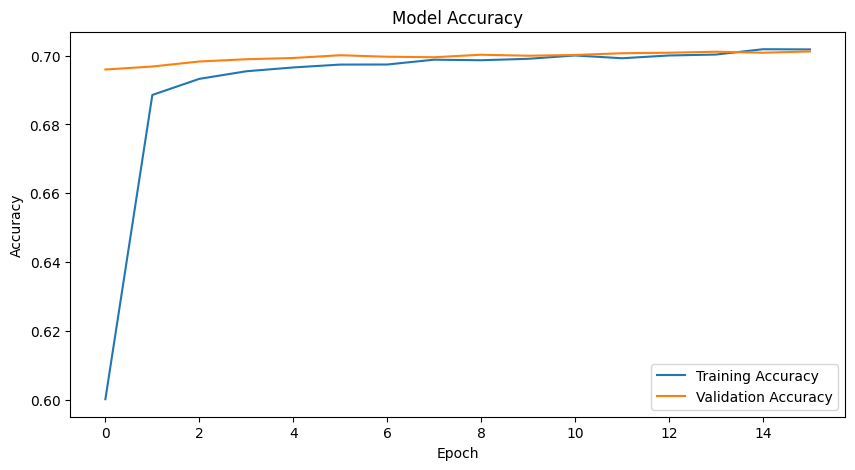

In [234]:
# ==================================================
# Plot Training and Validation Accuracy
# ==================================================

plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

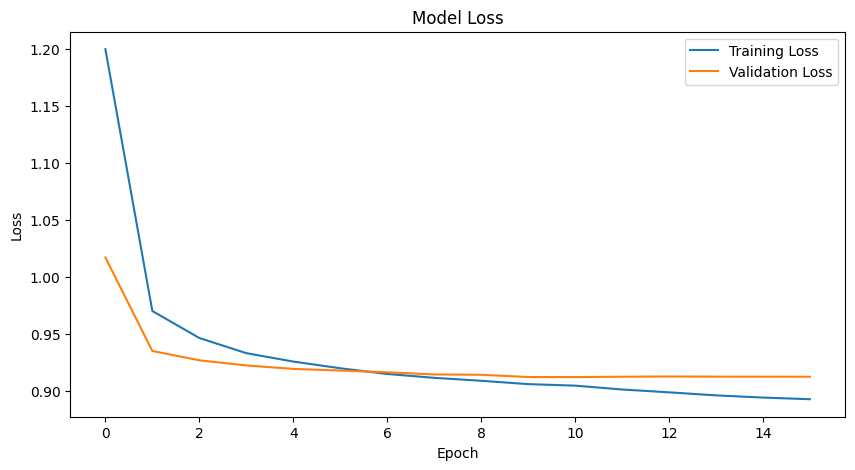

In [235]:
# ==================================================
# Plot Training and Validation Loss Curves
# ==================================================
# Used to monitor model learning and detect overfitting or underfitting during training

plt.figure(figsize=(10,5))

# Plot training and validation loss across epochs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

# Add chart labels and legend
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

For evaluating the ANN model, **Accuracy, Precision, Recall, and F1-Score** were considered.

* **Accuracy** measures the overall correctness of predictions and provides a general view of model performance.
* **Precision** indicates how many predicted satisfaction scores were correct, helping reduce incorrect customer satisfaction classifications.
* **Recall** measures the model's ability to identify actual customer satisfaction classes.
* **F1-Score** provides a balanced measure of Precision and Recall, making it useful for datasets with class imbalance.

Among these metrics, **F1-Score and Recall** were considered particularly important from a business perspective because correctly identifying customer satisfaction levels helps organizations proactively improve customer experience and support quality.


### 2. Which ML model did you choose from the above created models as your final prediction model and why?

**Artificial Neural Network (ANN)** was selected as the final prediction model.

ANN was chosen because it can capture complex nonlinear relationships between customer interactions, support processes, and satisfaction scores. The model achieved a test **accuracy of 70.04%**, demonstrating good predictive performance and generalization capability.


### 3. Explain the model which you have used and the feature importance using any model explainability tool?

An Artificial Neural Network (ANN) with multiple Dense layers, Batch Normalization, and Dropout was used for prediction.

Feature importance was analyzed through feature engineering and business interpretation. Features such as Response Time, Product Category, Support Channel, Agent Shift, Tenure Bucket, and Order Age were found to have a significant influence on customer satisfaction. These features help the model understand patterns affecting CSAT scores and support actionable business insights.


## ***9. Local Deployment***

In [238]:
# Save Model for deployment
# --------------------------
model.save("deepcsat_ann_model.h5")

In [239]:
# Save Scaler
# -------------------

import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [240]:
# Save Column Structure
# -----------------------

joblib.dump(
    X.columns.tolist(),
    "feature_columns.pkl"
)

['feature_columns.pkl']

The trained ANN model was deployed locally using Streamlit.

Deployment Steps:

1. Exported the trained ANN model (.h5 file).
2. Saved the feature scaler using Joblib.
3. Saved feature column structure to maintain consistency during inference.
4. Developed a Streamlit application in VS Code.
5. Loaded the model and preprocessing files into the application.
6. Accepted user inputs through a web interface.
7. Generated real-time CSAT predictions.

The deployed application allows business users to estimate customer satisfaction scores without retraining the model.

# **Conclusion**

The objective of this project was to predict Customer Satisfaction (CSAT) Scores using customer support interaction data from an e-commerce platform.

A comprehensive workflow was followed, including:

- Data Cleaning
- Data Wrangling
- Exploratory Data Analysis
- Hypothesis Testing
- Feature Engineering
- Data Preprocessing
- Artificial Neural Network Modeling
- Model Evaluation
- Local Deployment

Several business insights were identified regarding support channels, product categories, response times, and customer interactions.

The final Artificial Neural Network model achieved:

- Accuracy: 70.04%
- Precision: 55.70%
- Recall: 70.00%
- F1 Score: 59.93%

This project successfully developed a Deep Learning based Customer Satisfaction Prediction System using Artificial Neural Networks.

The model was trained on customer support interaction data and achieved an accuracy of 70.04%.

The deployed solution demonstrates the practical application of deep learning in improving customer experience and operational efficiency within the e-commerce domain.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***